# **Comparación de modelos jerárquicos**

## *Carga de paquetes y configuración*

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(gt)
})

# Parche para que las tablas gt se vean en Jupyter (mismo del EDA)
repr_html.gt_tbl <- function(obj, ...) gt::as_raw_html(obj)
repr_markdown.gt_tbl <- function(obj, ...) NULL
repr_latex.gt_tbl <- function(obj, ...) NULL
for (g in c("repr_html", "repr_markdown", "repr_latex")) {
  registerS3method(g, "gt_tbl", get(paste0(g, ".gt_tbl")), envir = asNamespace("repr"))
}

# Las rutas de config.R son relativas a la raíz del proyecto.
# Idempotente: si ya estamos en la raíz, no hace nada.
if (!file.exists("myst.yml") && file.exists("../myst.yml")) setwd("..")

if (file.exists(".Renviron")) readRenviron(".Renviron")

source("R/config.R")
source("R/data_prep.R")
source("R/moderation_pipeline.R")
source("R/model_comparison.R")
source("R/cross_validation.R")
source("R/elastic_net.R")

# Formato de p-valores usado en todas las tablas.
fmt_p <- function(x) ifelse(x < 0.001, "< .001", sub("^0", "", sprintf("%.3f", x)))

## *Modelos ajustados*

`load_fitted_models()` lee `outputs/models/fitted_models.rds`

In [2]:
models <- load_fitted_models()

cat(sprintf("Modelos cargados:      %d\n", length(models)))
cat(sprintf("N por modelo:          %d\n", attr(models, "n")))
cat(sprintf("Codificación género:   %s\n", attr(models, "gender_coding")))

Modelos cargados:      10


N por modelo:          530


Codificación género:   dummy


## *Índices de ajuste por modelo*

- **k** cuenta los parámetros de la verosimilitud: los coeficientes más la
  varianza residual.
- **ΔAIC** y **ΔBIC** se miden contra el mejor modelo del conjunto (el de
  valor mínimo, que queda en 0). Como referencia habitual, una diferencia
  menor que 2 indica modelos prácticamente equivalentes, y una mayor que 10,
  evidencia fuerte a favor del mejor.
- El **peso de Akaike** es la probabilidad relativa de que cada modelo sea el
  mejor (en el sentido de AIC) dentro de estos 10.

In [3]:
indices <- fit_indices(models)

indices %>%
  gt() %>%
  fmt_number(c(r_squared, adj_r_squared), decimals = 4) %>%
  fmt_number(c(log_lik, aic, bic, delta_aic, delta_bic), decimals = 2) %>%
  fmt_number(akaike_weight, decimals = 3) %>%
  cols_label(model = "Modelo", n = "N", k = "k",
             r_squared = "R²", adj_r_squared = "R² ajustado",
             log_lik = "log L", aic = "AIC", bic = "BIC",
             delta_aic = "ΔAIC", delta_bic = "ΔBIC",
             akaike_weight = "Peso de Akaike") %>%
  tab_header(title = "Índices de ajuste de los 10 modelos")

<div id="uzbomhkmsx" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#uzbomhkmsx table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#uzbomhkmsx thead, #uzbomhkmsx tbody, #uzbomhkmsx tfoot, #uzbomhkmsx tr, #uzbomhkmsx td, #uzbomhkmsx th {
  border-style: none;
}

#uzbomhkmsx p {
  margin: 0;
  padding: 0;
}

#uzbomhkmsx .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#uzbomhkmsx .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#uzbomhkmsx .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#uzbomhkmsx .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#uzbomhkmsx .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#uzbomhkmsx .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#uzbomhkmsx .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#uzbomhkmsx .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#uzbomhkmsx .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#uzbomhkmsx .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#uzbomhkmsx .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#uzbomhkmsx .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#uzbomhkmsx .gt_spanner_row {
  border-bottom-style: hidden;
}

#uzbomhkmsx .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

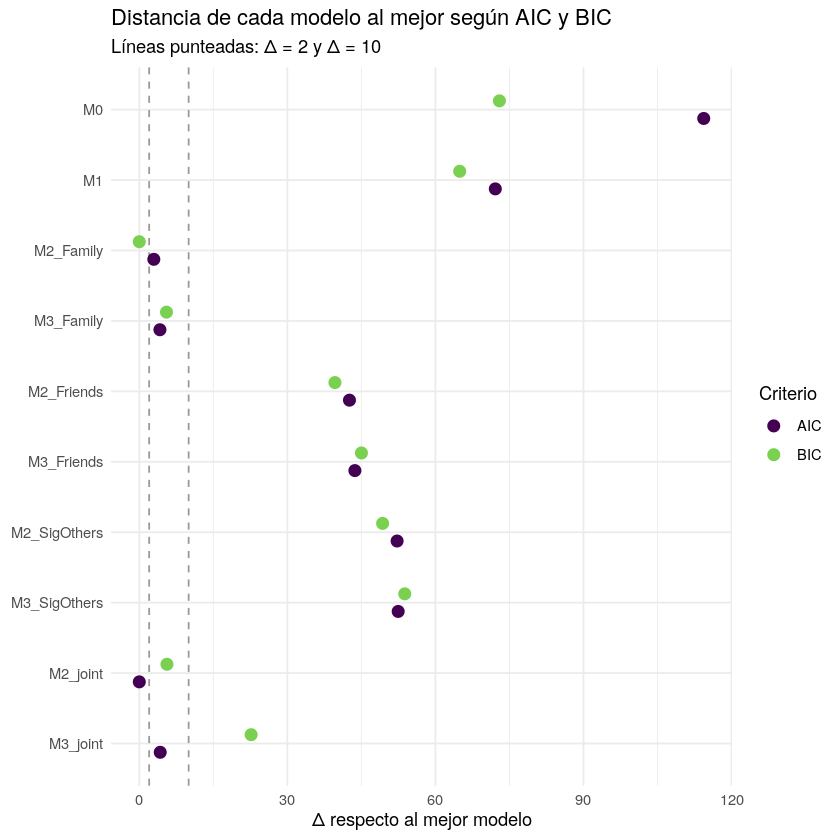

In [4]:
indices %>%
  select(model, AIC = delta_aic, BIC = delta_bic) %>%
  pivot_longer(-model, names_to = "Criterio", values_to = "delta") %>%
  mutate(model = factor(model, levels = rev(indices$model))) %>%
  ggplot(aes(x = delta, y = model, color = Criterio)) +
  geom_vline(xintercept = c(2, 10), linetype = "dashed", color = "grey60") +
  geom_point(size = 3, position = position_dodge(width = 0.5)) +
  scale_color_viridis_d(end = 0.8) +
  labs(title = "Distancia de cada modelo al mejor según AIC y BIC",
       subtitle = "Líneas punteadas: Δ = 2 y Δ = 10",
       x = "Δ respecto al mejor modelo", y = NULL) +
  theme_minimal()

Los dos criterios coinciden en que los mejores modelos incluyen el apoyo
familiar y no incluyen las interacciones con el género, aunque difieren en
cuál elegir: **AIC** prefiere **M2_joint** (las tres dimensiones sin interacción), con un peso de Akaike de 0.68. Por otro lado, **BIC** prefiere **M2_Family** (solo el apoyo familiar).

## *Comparaciones entre modelos anidados*

La secuencia de comparaciones se construye de la siguiente forma:

- **M0 → M1:** aporte del género y las covariables.
- **M1 → M2_D:** efecto principal de cada dimensión *D* del apoyo.
- **M2_D → M3_D:** interacción *D* × género, es decir, la moderación.
- **M1 → M2_joint** y **M2_joint → M3_joint:** lo mismo con las tres
  dimensiones a la vez.

En cada paso se reportan:

- **ΔR²**, el aumento de varianza explicada, y **f² de Cohen** del bloque,
  ΔR² / (1 − R² del modelo completo). Como referencia, 0.02, 0.15 y 0.35 se
  consideran efectos pequeño, mediano y grande.
- **Prueba F** clásica (`anova()`), que asume varianza residual constante.
- **LRT**, la prueba de razón de verosimilitud: 2 × (log L completo − log L
  reducido)
- **ΔAIC y ΔBIC**
- **F (HC3)**

In [5]:
nested <- compare_nested(models)

nested %>%
  mutate(paso = sprintf("%s → %s", reduced, full)) %>%
  select(paso, block, df_added, delta_r2, cohen_f2,
         f_stat, p_f, lr_stat, p_lr, delta_aic, delta_bic, f_hc3, p_hc3) %>%
  gt() %>%
  fmt_number(c(delta_r2, cohen_f2), decimals = 4) %>%
  fmt_number(c(f_stat, lr_stat, f_hc3, delta_aic, delta_bic), decimals = 2) %>%
  fmt(c(p_f, p_lr, p_hc3), fns = fmt_p) %>%
  cols_label(paso = "Paso", block = "Bloque agregado", df_added = "gl",
             delta_r2 = "ΔR²", cohen_f2 = "f²",
             f_stat = "F", p_f = "p (F)",
             lr_stat = "LR", p_lr = "p (LR)",
             delta_aic = "ΔAIC", delta_bic = "ΔBIC",
             f_hc3 = "F (HC3)", p_hc3 = "p (HC3)") %>%
  tab_spanner("Varianza explicada", c(delta_r2, cohen_f2)) %>%
  tab_spanner("Prueba F", c(f_stat, p_f)) %>%
  tab_spanner("Verosimilitud", c(lr_stat, p_lr, delta_aic, delta_bic)) %>%
  tab_spanner("Robusta", c(f_hc3, p_hc3)) %>%
  tab_header(title = "Comparaciones entre modelos anidados",
             subtitle = "ΔAIC y ΔBIC: completo − reducido (negativo favorece al completo)")

<div id="xblsviteav" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#xblsviteav table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#xblsviteav thead, #xblsviteav tbody, #xblsviteav tfoot, #xblsviteav tr, #xblsviteav td, #xblsviteav th {
  border-style: none;
}

#xblsviteav p {
  margin: 0;
  padding: 0;
}

#xblsviteav .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#xblsviteav .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#xblsviteav .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#xblsviteav .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#xblsviteav .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#xblsviteav .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#xblsviteav .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#xblsviteav .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#xblsviteav .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#xblsviteav .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#xblsviteav .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#xblsviteav .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#xblsviteav .gt_spanner_row {
  border-bottom-style: hidden;
}

#xblsviteav .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

**Género y covariables (M0 → M1).** Explican el 10.4 % de la varianza del
*entrapment* (f² = 0.12, p < .001 con las tres pruebas). Este bloque está
dominado por el género, cuyo coeficiente es significativo en todos los
modelos.

**Efectos principales del apoyo (M1 → M2).** Las tres dimensiones aportan por
sí solas y de forma significativa (p < .001 con las tres pruebas), pero con
magnitudes muy distintas: **Family**: ΔR² = 0.113 y f² = 0.14, un efecto cercano a mediano, **Friends**: ΔR² = 0.052 y f² = 0.06, un efecto pequeño. y**SigOthers**: ΔR² = 0.036 y f² = 0.04, también pequeño.

Las tres juntas (M1 → M2_joint) agregan ΔR² = 0.123, apenas 0.010 más que el
apoyo familiar solo. Buena parte de lo que explican amigos y otras personas
significativas ya está contenido en el apoyo familiar.

**Moderación por género (M2 → M3).** Ninguna interacción es significativa con
ninguna de las pruebas. Los ΔR² van de 0.001 a 0.003 y los f² son menores que
0.004, muy por debajo del umbral de un efecto pequeño (0.02). AIC y BIC
empeoran al agregar cada interacción (ΔAIC entre +0.2 y +4.2; ΔBIC entre +4.5
y +17.1).

**Pruebas robustas.** La prueba F clásica, la LRT y la Wald con HC3 llevan a
las mismas conclusiones en los nueve pasos. Los resultados no dependen del
supuesto de varianza constante.

## *Predicción fuera de muestra*

`fit_models.ipynb` evaluó los 11 modelos con validación cruzada repetida
(10 folds × 20 repeticiones, estratificada por género y con el preprocesamiento
aprendido en cada fold). Elastic net volvió a elegir α y λ dentro de cada fold
de entrenamiento. Aquí se resumen esos errores. Se reporta:

- El **EE** de cada métrica se calcula en cada repetición como
  sd(folds) / √K y se promedia entre repeticiones. 
- **ΔRMSE pareado** es la diferencia media con el mejor modelo, calculada fold
  a fold sobre las mismas particiones, con su propio EE.
- **Regla de 1 EE**: el mejor modelo es el de menor RMSE medio y el umbral es
  su RMSE más 1 EE. Se reportan los modelos cuyo RMSE medio no supera el
  umbral; **no se elige uno**.
- **Coeficientes:** en los `lm()` es fijo; en elastic net es el promedio entre
  folds de las columnas distintas de cero más el intercepto, porque sus
  columnas se eligen en cada fold.

In [6]:
cv_results <- load_cv_results()
cv_summary <- summarise_cv(cv_results)

cat(sprintf("Modelos:             %d\n", n_distinct(cv_results$model)))
cat(sprintf("Particiones:         %d\n", n_distinct(paste(cv_results$repeat_id, cv_results$fold))))
cat(sprintf("Mejor RMSE medio:    %s\n", attr(cv_summary, "best")))
cat(sprintf("Umbral (%g EE):       %.4f\n", attr(cv_summary, "se_rule"), attr(cv_summary, "threshold")))
cat(sprintf("Dentro de 1 EE:      %s\n",
            paste(cv_summary$model[cv_summary$within_se_rule], collapse = ", ")))

Modelos:             11


Particiones:         200


Mejor RMSE medio:    M2_joint


Umbral (1 EE):       0.8945


Dentro de 1 EE:      M2_Family, M3_Family, M2_joint, M3_joint, ElasticNet


In [7]:
cv_summary %>%
  mutate(Estado = case_when(is_best ~ "Mejor RMSE",
                            within_se_rule ~ "Dentro de 1 EE",
                            TRUE ~ "")) %>%
  select(model, n_coef, rmse_mean, rmse_se, delta_rmse, delta_rmse_se,
         mae_mean, r2_mean, Estado) %>%
  gt() %>%
  fmt_number(n_coef, decimals = 1, drop_trailing_zeros = TRUE) %>%
  fmt_number(c(rmse_mean, rmse_se, delta_rmse, delta_rmse_se, mae_mean, r2_mean),
             decimals = 4) %>%
  cols_label(model = "Modelo", n_coef = "Coeficientes",
             rmse_mean = "RMSE", rmse_se = "EE",
             delta_rmse = "ΔRMSE", delta_rmse_se = "EE (Δ)",
             mae_mean = "MAE", r2_mean = "R² fuera de muestra") %>%
  tab_spanner("Diferencia pareada con el mejor", c(delta_rmse, delta_rmse_se)) %>%
  tab_style(style = cell_text(weight = "bold"),
            locations = cells_body(rows = Estado != "")) %>%
  tab_header(title = "Error de predicción fuera de muestra",
             subtitle = sprintf("%d folds × %d repeticiones, estratificado por %s",
                                CV_FOLDS, CV_REPEATS, CV_STRATA_VAR))

<div id="gaqhjmakut" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#gaqhjmakut table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#gaqhjmakut thead, #gaqhjmakut tbody, #gaqhjmakut tfoot, #gaqhjmakut tr, #gaqhjmakut td, #gaqhjmakut th {
  border-style: none;
}

#gaqhjmakut p {
  margin: 0;
  padding: 0;
}

#gaqhjmakut .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#gaqhjmakut .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#gaqhjmakut .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#gaqhjmakut .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#gaqhjmakut .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#gaqhjmakut .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#gaqhjmakut .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#gaqhjmakut .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#gaqhjmakut .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#gaqhjmakut .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#gaqhjmakut .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#gaqhjmakut .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#gaqhjmakut .gt_spanner_row {
  border-bottom-style: hidden;
}

#gaqhjmakut .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

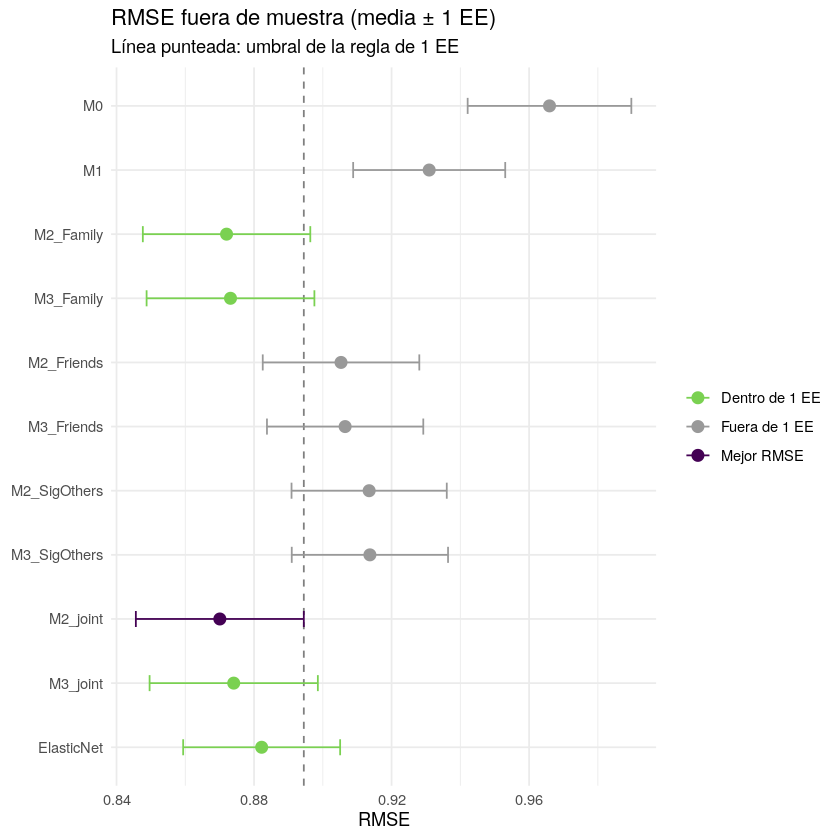

In [8]:
cv_summary %>%
  mutate(model = fct_rev(model),
         Estado = case_when(is_best ~ "Mejor RMSE",
                            within_se_rule ~ "Dentro de 1 EE",
                            TRUE ~ "Fuera de 1 EE")) %>%
  ggplot(aes(x = rmse_mean, y = model, color = Estado)) +
  geom_vline(xintercept = attr(cv_summary, "threshold"),
             linetype = "dashed", color = "grey50") +
  geom_errorbar(aes(xmin = rmse_mean - rmse_se, xmax = rmse_mean + rmse_se),
                width = 0.25, orientation = "y") +
  geom_point(size = 3) +
  scale_color_manual(values = c("Mejor RMSE"     = viridisLite::viridis(10, end = 0.8)[1],
                                "Dentro de 1 EE" = viridisLite::viridis(10, end = 0.8)[10],
                                "Fuera de 1 EE"  = "grey60")) +
  labs(title = "RMSE fuera de muestra (media ± 1 EE)",
       subtitle = "Línea punteada: umbral de la regla de 1 EE",
       x = "RMSE", y = NULL, color = NULL) +
  theme_minimal()

M2_joint tiene el menor error fuera de muestra (RMSE = 0.870,
EE = 0.024), seguido muy de cerca por M2_Family (0.872). El umbral de la regla
de 1 EE queda en 0.894. Cinco modelos no se distinguen del mejor: los cuatro
modelos que incluyen el apoyo familiar (M2_Family, M3_Family, M2_joint y
M3_joint) y elastic net. Los modelos sin el apoyo familiar (M2_Friends,
M2_SigOthers y sus M3) y los que no tienen ninguna dimensión del apoyo (M0 y
M1) quedan fuera.

Cada M3 predice peor que su M2. La diferencia más clara es
M3_joint frente a M2_joint (+0.004, EE = 0.002): los tres términos de
interacción solo agregan ruido.

### *Criterios de información frente a validación cruzada*

In [9]:
cv_summary %>%
  transmute(model = as.character(model), rmse_mean, delta_rmse, within_se_rule) %>%
  left_join(indices %>% select(model, delta_aic, delta_bic), by = "model") %>%
  select(model, delta_aic, delta_bic, rmse_mean, delta_rmse, within_se_rule) %>%
  gt() %>%
  fmt_number(c(delta_aic, delta_bic), decimals = 2) %>%
  fmt_number(c(rmse_mean, delta_rmse), decimals = 4) %>%
  sub_missing(missing_text = "—") %>%
  text_transform(locations = cells_body(columns = within_se_rule),
                 fn = function(x) ifelse(x == "TRUE", "sí", "no")) %>%
  cols_label(model = "Modelo", delta_aic = "ΔAIC", delta_bic = "ΔBIC",
             rmse_mean = "RMSE (CV)", delta_rmse = "ΔRMSE (CV)",
             within_se_rule = "Dentro de 1 EE") %>%
  tab_header(title = "Criterios de información frente a validación cruzada",
             subtitle = "Δ medido contra el mejor modelo de cada criterio; elastic net no tiene AIC / BIC")

<div id="jdtoxospts" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#jdtoxospts table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#jdtoxospts thead, #jdtoxospts tbody, #jdtoxospts tfoot, #jdtoxospts tr, #jdtoxospts td, #jdtoxospts th {
  border-style: none;
}

#jdtoxospts p {
  margin: 0;
  padding: 0;
}

#jdtoxospts .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#jdtoxospts .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#jdtoxospts .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#jdtoxospts .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#jdtoxospts .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#jdtoxospts .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#jdtoxospts .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#jdtoxospts .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#jdtoxospts .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#jdtoxospts .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#jdtoxospts .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#jdtoxospts .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#jdtoxospts .gt_spanner_row {
  border-bottom-style: hidden;
}

#jdtoxospts .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

AIC y BIC no coinciden: AIC prefiere M2_joint y BIC prefiere M2_Family. Los
dos quedan dentro de 1 EE en la validación cruzada, que no distingue entre
ellos. El menor RMSE coincide con el menor AIC (M2_joint).

### *Elastic net frente a los modelos jerárquicos: ΔR²*

ΔR² = R² de elastic net − R² del modelo jerárquico; un valor positivo favorece
a elastic net. Se reporta de dos formas: dentro de muestra y fuera de muestra.

In [10]:
en_model  <- load_en_model()
r2_en_in  <- en_r_squared(en_model, build_clean_sample())
r2_en_oos <- cv_summary$r2_mean[cv_summary$model == EN_MODEL_NAME]

delta_r2 <- indices %>%
  select(model, r2_in = r_squared) %>%
  mutate(delta_in = r2_en_in - r2_in) %>%
  left_join(cv_summary %>% transmute(model = as.character(model), r2_oos = r2_mean),
            by = "model") %>%
  left_join(paired_delta(cv_results, reference = EN_MODEL_NAME, metric = "r2_oos") %>%
              transmute(model = as.character(model),
                        delta_oos = -delta, delta_oos_se = delta_se),
            by = "model")

cat(sprintf("R² de elastic net dentro de muestra: %.4f\n", r2_en_in))
cat(sprintf("R² de elastic net fuera de muestra:  %.4f\n", r2_en_oos))

delta_r2 %>%
  gt() %>%
  fmt_number(-model, decimals = 4) %>%
  cols_label(model = "Modelo",
             r2_in = "R² del modelo", delta_in = "ΔR²",
             r2_oos = "R² del modelo", delta_oos = "ΔR²", delta_oos_se = "EE (Δ)") %>%
  tab_spanner(sprintf("Dentro de muestra (EN: %.4f)", r2_en_in), c(r2_in, delta_in)) %>%
  tab_spanner(sprintf("Fuera de muestra (EN: %.4f)", r2_en_oos), c(r2_oos, delta_oos, delta_oos_se)) %>%
  tab_header(title = "ΔR² de elastic net frente a cada modelo jerárquico",
             subtitle = "ΔR² = R² de elastic net − R² del modelo")

R² de elastic net dentro de muestra: 0.1971


R² de elastic net fuera de muestra:  0.1630


<div id="lyykdvgkck" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#lyykdvgkck table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#lyykdvgkck thead, #lyykdvgkck tbody, #lyykdvgkck tfoot, #lyykdvgkck tr, #lyykdvgkck td, #lyykdvgkck th {
  border-style: none;
}

#lyykdvgkck p {
  margin: 0;
  padding: 0;
}

#lyykdvgkck .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#lyykdvgkck .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#lyykdvgkck .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#lyykdvgkck .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#lyykdvgkck .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#lyykdvgkck .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#lyykdvgkck .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#lyykdvgkck .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#lyykdvgkck .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#lyykdvgkck .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#lyykdvgkck .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#lyykdvgkck .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#lyykdvgkck .gt_spanner_row {
  border-bottom-style: hidden;
}

#lyykdvgkck .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

**Dentro de muestra.** Elastic net explica el 19.7 % de la varianza: entre 2
y 3 puntos menos que los modelos con el apoyo familiar, y entre 4 y 6 puntos
más que los modelos con una sola dimensión distinta de la familiar. Que quede
por debajo de los mejores `lm()` es esperable: sus coeficientes están
encogidos y no maximizan el ajuste a estos datos.

**Fuera de muestra** tenemos las siguientes comparaciones:

- **Frente a los modelos con el apoyo familiar** (M2_Family, M3_Family,
  M2_joint, M3_joint), el ΔR² va de −0.019 a −0.011, con EE cercanos a 0.02:
  elastic net predice prácticamente igual.
- **Frente a M1 y a los modelos de otras personas significativas**, elastic
  net predice claramente mejor: +0.096 frente a M1 (EE = 0.026) y +0.062
  frente a M2_SigOthers (EE = 0.024).
- **Frente a los modelos de amigos**, la ventaja es de +0.047 a +0.050
  (EE = 0.028), menos nítida porque no llega a 2 EE.

## *Supuestos de los modelos lineales*

Se prueban los supuestos del modelo lineal en los 11 modelos ajustados con los
530 casos. 

| Supuesto | Prueba | Se cumple si |
|---|---|---|
| Normalidad de los residuos | Shapiro-Wilk | p ≥ 0.05 |
| Homocedasticidad | Breusch-Pagan (Koenker) | p ≥ 0.05 |
| Independencia | Durbin-Watson | p ≥ 0.05 |
| Linealidad (forma funcional) | RESET de Ramsey (ajustado² y ajustado³) | p ≥ 0.05 |
| Multicolinealidad | VIF máximo | VIF < 5 |

En M0 (solo intercepto) no hay predictores, así que la homocedasticidad, la
linealidad y la multicolinealidad no aplican.

In [11]:
assumptions <- assumption_tests(models, load_en_model(), build_clean_sample())

celda <- function(ok, p) {
  case_when(is.na(ok) ~ "—",
            TRUE ~ sprintf("%s (p %s)", ifelse(ok, "sí", "no"),
                           ifelse(p < 0.001, "< .001", paste("=", sub("^0", "", sprintf("%.3f", p))))))
}

assumptions %>%
  transmute(
    Modelo           = model,
    Normalidad       = celda(normality_ok, shapiro_p),
    Homocedasticidad = celda(homosced_ok, bp_p),
    Independencia    = celda(independence_ok, dw_p),
    Linealidad       = celda(linearity_ok, reset_p),
    Multicolinealidad = ifelse(is.na(collinearity_ok), "—",
                               sprintf("%s (VIF = %.2f)", ifelse(collinearity_ok, "sí", "no"), vif_max)),
    `Cumple todas`   = ifelse(all_met, "sí", "no")
  ) %>%
  gt() %>%
  tab_spanner("Shapiro-Wilk", Normalidad) %>%
  tab_spanner("Breusch-Pagan", Homocedasticidad) %>%
  tab_spanner("Durbin-Watson", Independencia) %>%
  tab_spanner("RESET", Linealidad) %>%
  tab_spanner("VIF máximo", Multicolinealidad) %>%
  tab_style(style = cell_text(color = "#B03A2E"),
            locations = list(
              cells_body(columns = Normalidad,       rows = str_starts(Normalidad, "no")),
              cells_body(columns = Homocedasticidad, rows = str_starts(Homocedasticidad, "no")),
              cells_body(columns = Independencia,    rows = str_starts(Independencia, "no")),
              cells_body(columns = Linealidad,       rows = str_starts(Linealidad, "no")),
              cells_body(columns = Multicolinealidad, rows = str_starts(Multicolinealidad, "no")),
              cells_body(columns = `Cumple todas`,   rows = `Cumple todas` == "no"))) %>%
  tab_header(title = "Supuestos del modelo lineal",
             subtitle = sprintf("α = %.2f; VIF máximo tolerado = %g", ASSUMPTION_ALPHA, ASSUMPTION_VIF_MAX))

<div id="abbpkvoozz" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#abbpkvoozz table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#abbpkvoozz thead, #abbpkvoozz tbody, #abbpkvoozz tfoot, #abbpkvoozz tr, #abbpkvoozz td, #abbpkvoozz th {
  border-style: none;
}

#abbpkvoozz p {
  margin: 0;
  padding: 0;
}

#abbpkvoozz .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#abbpkvoozz .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#abbpkvoozz .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#abbpkvoozz .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#abbpkvoozz .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#abbpkvoozz .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#abbpkvoozz .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#abbpkvoozz .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#abbpkvoozz .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#abbpkvoozz .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#abbpkvoozz .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#abbpkvoozz .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#abbpkvoozz .gt_spanner_row {
  border-bottom-style: hidden;
}

#abbpkvoozz .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

**Ningún modelo cumple todos los supuestos.** El que falla en los 11 es la
normalidad, los demás se cumplen en la mayoría de los modelos.

## *Guardado*

- `outputs/tables/fit_indices.csv`: índices de ajuste de los 10 `lm()`.
- `outputs/tables/nested_tests.csv`: comparaciones entre modelos anidados.
- `outputs/tables/assumption_tests.csv`: pruebas de supuestos de los 11
  modelos.
- `outputs/tables/cv_summary.csv`: resumen de la validación cruzada de los 11
  modelos, con la regla de 1 EE.

In [12]:
saved <- c(save_comparison_outputs(indices, nested, assumptions),
           save_cv_summary(cv_summary))

cat(paste(saved, collapse = "\n"), "\n")

outputs/tables/fit_indices.csv
outputs/tables/nested_tests.csv
outputs/tables/assumption_tests.csv
outputs/tables/cv_summary.csv 
